## Load the dataset

In [68]:
import kagglehub, glob, os
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
print("Path to dataset files:", path)

# This returns a list of paths
csv_files = glob.glob(os.path.join(path, '*.csv'))

# load explicitly instead of relying on index [0]
data_path = [f for f in csv_files if 'dictionary' not in f.lower()][0]
df = pd.read_csv(data_path)
print(df.shape)
print(df.head())

Path to dataset files: /Users/saleh/.cache/kagglehub/datasets/rohan0301/unsupervised-learning-on-country-data/versions/2
(167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [70]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Standardize the data

In [71]:
from sklearn.preprocessing import StandardScaler

num_cols = df.drop(columns='country')

scaler = StandardScaler()
scaled = scaler.fit_transform(num_cols)

scaled_df = pd.DataFrame(scaled, columns=num_cols.columns)
scaled_df['country'] = df['country'].values

## Process the model

Without PCA:

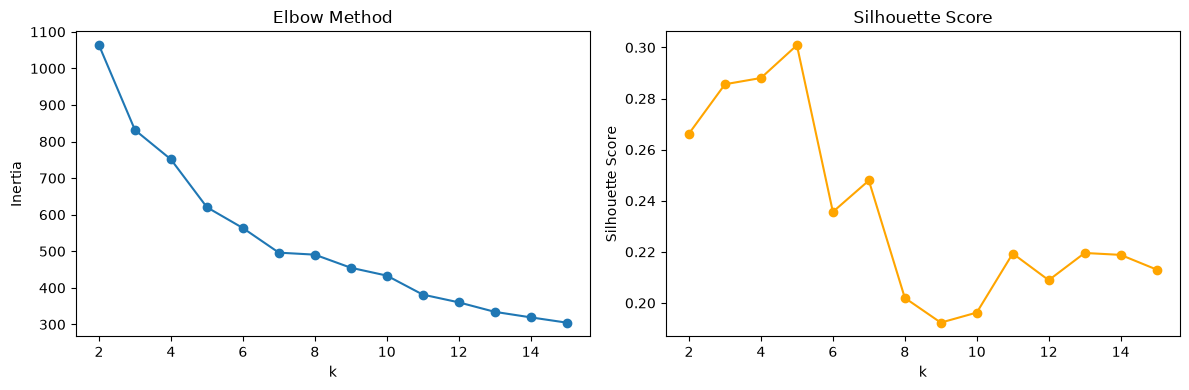

k=2: silhouette=0.2663
k=3: silhouette=0.2856
k=4: silhouette=0.2880
k=5: silhouette=0.3009
k=6: silhouette=0.2357
k=7: silhouette=0.2479
k=8: silhouette=0.2020
k=9: silhouette=0.1923
k=10: silhouette=0.1962
k=11: silhouette=0.2194
k=12: silhouette=0.2089
k=13: silhouette=0.2196
k=14: silhouette=0.2188
k=15: silhouette=0.2131


In [72]:
import sklearn as skl
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

k_range = range(2, 16)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled, labels))

# chart
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_range, inertias, marker='o')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method')

ax[1].plot(k_range, sil_scores, marker='o', color='orange')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

With PCA:

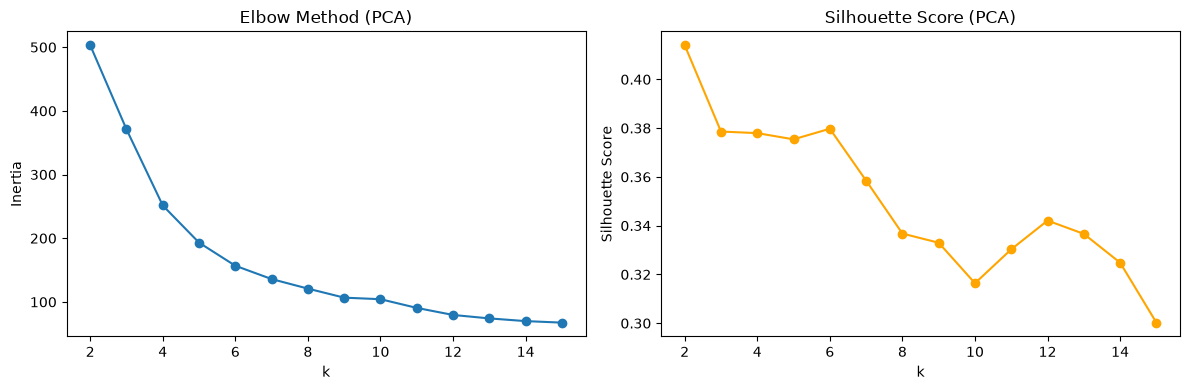

k=2: silhouette=0.4140
k=3: silhouette=0.3786
k=4: silhouette=0.3779
k=5: silhouette=0.3754
k=6: silhouette=0.3797
k=7: silhouette=0.3585
k=8: silhouette=0.3368
k=9: silhouette=0.3330
k=10: silhouette=0.3164
k=11: silhouette=0.3303
k=12: silhouette=0.3421
k=13: silhouette=0.3366
k=14: silhouette=0.3248
k=15: silhouette=0.3002


In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 16)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(pca_result)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pca_result, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_range, inertias, marker='o')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method (PCA)')

ax[1].plot(k_range, sil_scores, marker='o', color='orange')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score (PCA)')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

In [74]:
best_k = 6
kmeans_pca = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
df['cluster_pca'] = kmeans_pca.fit_predict(pca_result)

for c in sorted(df['cluster_pca'].unique()):
    print(f"\nCluster {c}:")
    print(df[df['cluster_pca'] == c]['country'].tolist())


Cluster 0:
['Albania', 'Algeria', 'Argentina', 'Armenia', 'Azerbaijan', 'Bangladesh', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Georgia', 'Grenada', 'Guatemala', 'India', 'Indonesia', 'Iran', 'Iraq', 'Jamaica', 'Kazakhstan', 'Micronesia, Fed. Sts.', 'Morocco', 'Myanmar', 'Nepal', 'Paraguay', 'Peru', 'Philippines', 'Romania', 'Russia', 'Rwanda', 'Samoa', 'Serbia', 'South Africa', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Suriname', 'Tonga', 'Turkey', 'Ukraine', 'Uruguay', 'Uzbekistan', 'Venezuela']

Cluster 1:
['Antigua and Barbuda', 'Bahamas', 'Bahrain', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Brunei', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Estonia', 'Hungary', 'Ireland', 'Jordan', 'Kuwait', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Moldova', 'Montenegro', 'Oman', 'Panama', 'Poland', 'S

### Choose the best K for our clustering which is `K=6`

In [75]:
best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(scaled)

### Plotting Income vs GDPP

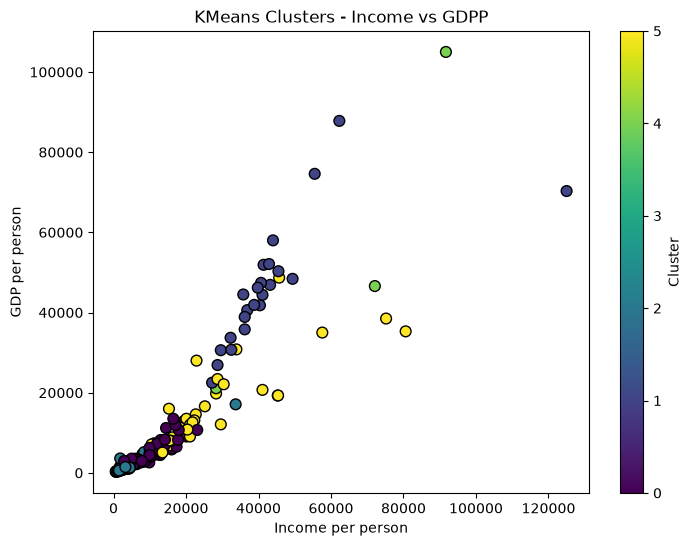

In [76]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['income'], df['gdpp'], 
                       c=df['cluster'], cmap='viridis', s=60, edgecolor='k')
plt.xlabel('Income per person')
plt.ylabel('GDP per person')
plt.title('KMeans Clusters - Income vs GDPP')
plt.colorbar(scatter, label='Cluster')
plt.show()

### Plotting Child Mortality vs Income

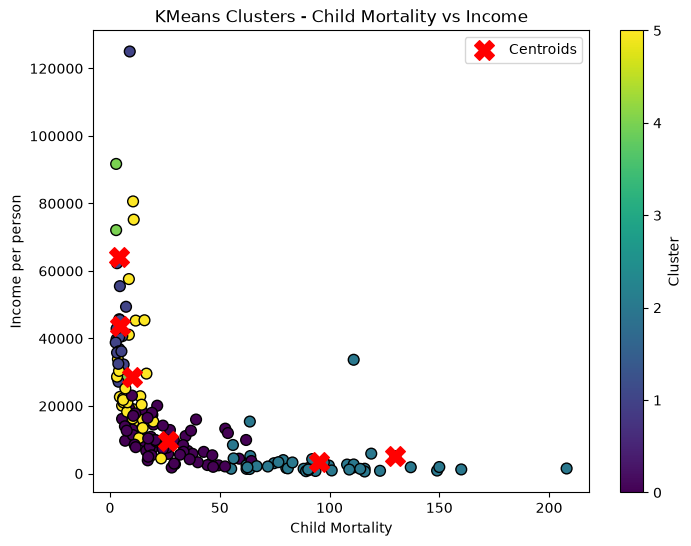

In [77]:
# Inverse transform centroids back to original feature scale
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=num_cols.columns)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['child_mort'], df['income'], 
                       c=df['cluster'], cmap='viridis', s=60, edgecolor='k')

plt.scatter(centroids_df['child_mort'], centroids_df['income'], 
            c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Child Mortality')
plt.ylabel('Income per person')
plt.title('KMeans Clusters - Child Mortality vs Income')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

### Getting the important features

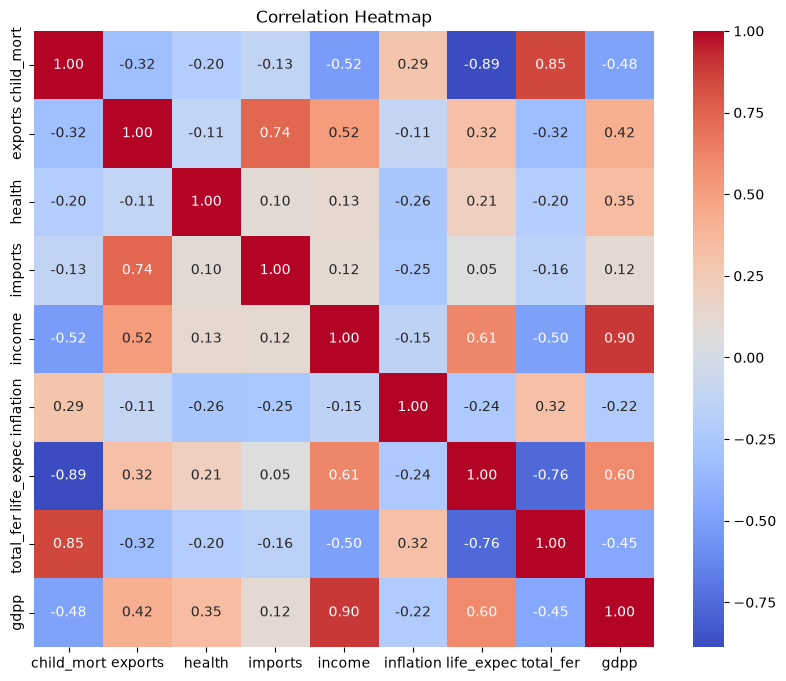

In [78]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Plotting the important features vs Income

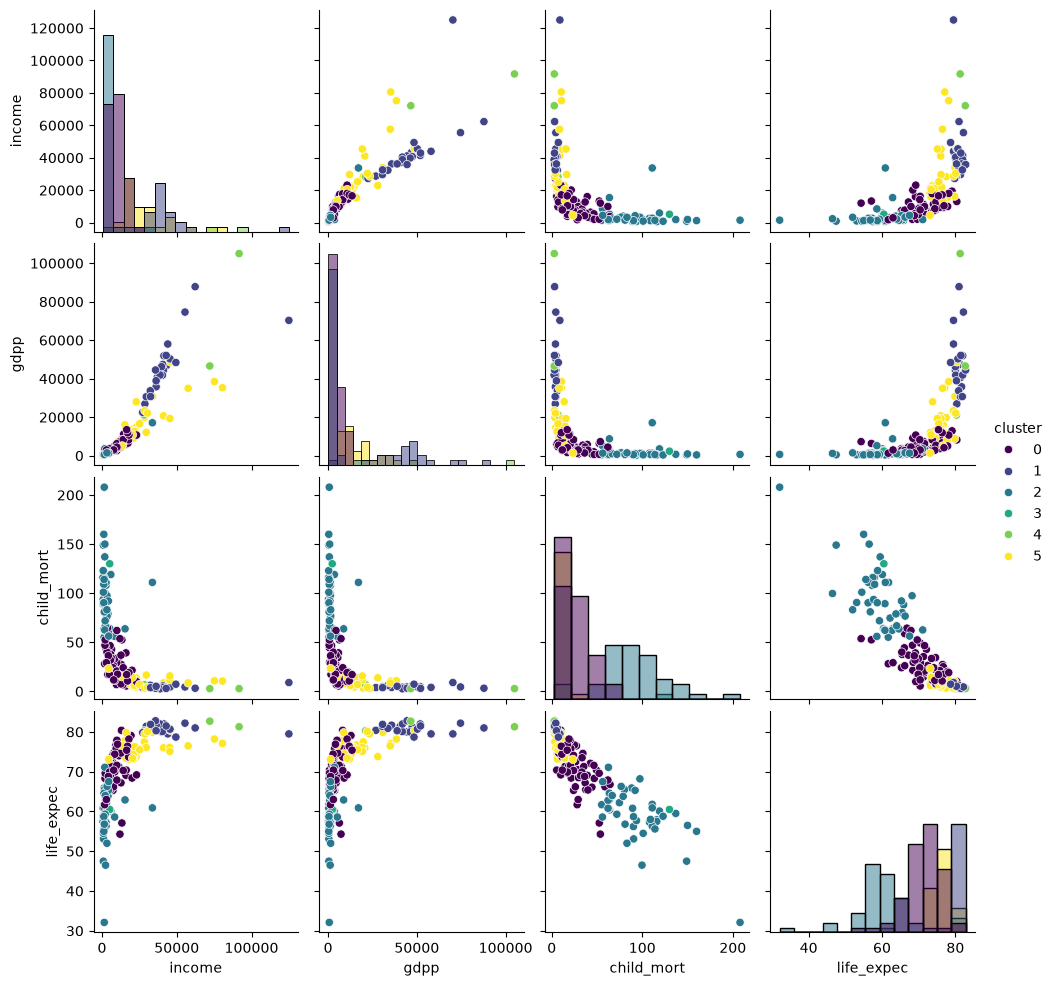

In [79]:
important_cols = ['income', 'gdpp', 'child_mort', 'life_expec', 'cluster']
sns.pairplot(df[important_cols], hue='cluster', palette='viridis', diag_kind='hist')
plt.show()

### Feature reduction using PCA

Explained variance ratio: [0.4595174  0.17181626]
Total explained variance: 0.631333654377141


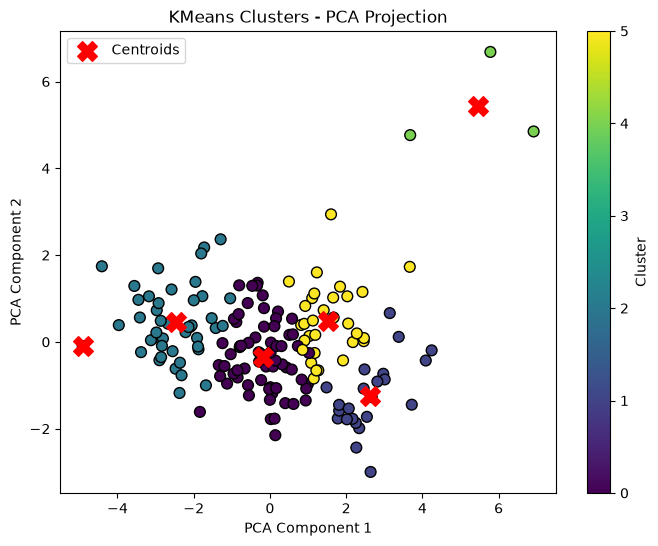

In [80]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Project the cluster centroids into the same PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                       c=df['cluster'], cmap='viridis', s=60, edgecolor='k')

# Plot centroids as red X markers
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters - PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.show()

As we can see we have an outliers on top right and on left, and this is a big downside of `KMeans()`; because it can not identify noise points.

## Giving the clusters meaningful names

In [81]:
cluster_profile = df.groupby('cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()
print(cluster_profile)

         child_mort        income          gdpp  life_expec
cluster                                                    
0         26.322727   9619.393939   4755.333333   71.372727
1          4.504348  43713.043478  46356.521739   80.852174
2         95.258140   3305.651163   1625.395349   59.132558
3        130.000000   5150.000000   2330.000000   60.500000
4          4.133333  64033.333333  57566.666667   81.433333
5         10.054839  28499.677419  17420.645161   76.293548


In [82]:
cluster_names = {
    0: 'Developing',
    1: 'Developed',
    2: 'Needs Aid',
    3: 'Critical Need',     #  Nigeria
    4: 'Ultra High Income'  #  Very rich small countries
}

df['cluster_name'] = df['cluster'].map(cluster_names)
print(df[['country', 'cluster', 'cluster_name']].head(10))

               country  cluster cluster_name
0          Afghanistan        2    Needs Aid
1              Albania        0   Developing
2              Algeria        0   Developing
3               Angola        2    Needs Aid
4  Antigua and Barbuda        5          NaN
5            Argentina        0   Developing
6              Armenia        0   Developing
7            Australia        1    Developed
8              Austria        1    Developed
9           Azerbaijan        0   Developing


## KMeans Conclusion (Plot)

Explained variance ratio: [0.4595174  0.17181626]
Total explained variance: 0.631333654377141


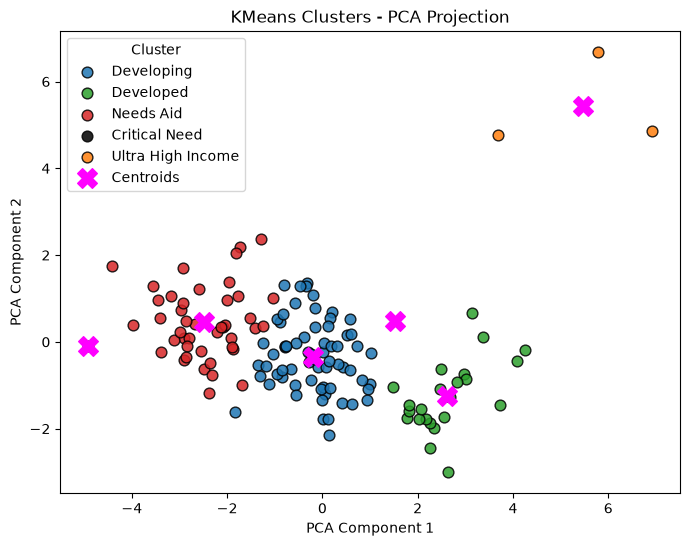

In [83]:
color_map = {
    'Developing': '#1f77b4',        # blue
    'Developed': '#2ca02c',         # green
    'Needs Aid': '#d62728',         # red
    'Critical Need': '#000000',     # black
    'Ultra High Income': '#ff7f0e'  # orange
}

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Project the cluster centroids into the same PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))

for name, color in color_map.items():
    mask = df['cluster_name'] == name
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                label=name, color=color, s=60, edgecolor='k', alpha=0.85)

# Plot centroids as black X markers (changed from red to stand out against black cluster color)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='magenta', marker='X', s=200, label='Centroids')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clusters - PCA Projection')
plt.legend(title='Cluster', loc='best')
plt.show()

## DBSCAN
Fixing the "noise" points by using the `DBSCAN`

Manually building our `GridSearch` since we can't use the sklearn bulit-in function, because we don't have the (y) labels.

In [94]:
from sklearn.cluster import DBSCAN
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.model_selection import GridSearchCV
import itertools

eps_values = np.arange(0.3, 2.0, 0.1)
min_samples_values = (range(3,10))

best_score = -1
best_params = None
results = []

for eps, min_samples in itertools.product(eps_values, min_samples_values):
    db=DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(pca_result)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters < 2:
        continue
    
    mask = labels != -1
    if mask.sum() < 2:
        continue
    
    score = silhouette_score(pca_result[mask], labels[mask])
    results.append((eps, min_samples, n_clusters, n_noise, score))
    
    if score > best_score:
        best_score = score
        best_params = (eps, min_samples)

print(f"Best eps and min_samples: {best_params}")
print(f"Best silhouette score: {best_score:.4f}")

results_df = pd.DataFrame(results, columns=['eps', 'min_samples', 'n_clusters', 'n_noise', 'silhouette'])
print(results_df.sort_values('silhouette', ascending=False).head(10))

Best eps and min_samples: (np.float64(0.3), 6)
Best silhouette score: 0.6898
    eps  min_samples  n_clusters  n_noise  silhouette
3   0.3            6           3      146    0.689760
9   0.4            8           5      113    0.599015
2   0.3            5           7      118    0.598800
10  0.4            9           2      140    0.573624
1   0.3            4          10       89    0.534334
8   0.4            7           6       94    0.492919
0   0.3            3          18       56    0.442843
21  0.6            9           3       44    0.423678
20  0.6            8           3       41    0.419687
15  0.5            7           3       49    0.387591


### Why We Didn't Pick the Highest Silhouette Score for DBSCAN

When grid-searching `eps` and `min_samples` for DBSCAN, the combination with the
**highest silhouette score (0.6898)** used `eps=0.3, min_samples=6`, but this came
at the cost of labeling **146 out of 167 countries (87%) as noise**. Only 21
countries were actually assigned to a real cluster.

This is a classic pitfall with DBSCAN: silhouette score is only calculated on the
non-noise points. If the algorithm throws away almost all "difficult" or
borderline countries and keeps just a small handful of very similar points, the
silhouette score looks artificially excellent — but the result is practically
useless, since it fails to classify the vast majority of the dataset.

**Instead, we selected `eps=0.6, min_samples=8` (silhouette = 0.4197, 41 noise
points / ~25%)** because it offers a much better balance:

| eps | min_samples | n_clusters | n_noise | silhouette |
|-----|-------------|------------|---------|------------|
| 0.3 | 6           | 3          | 146     | 0.6898     |
| 0.6 | 8           | 3          | 41      | 0.4197     |

A lower silhouette score with far less noise is more useful in practice — it
means the model actually clusters most of the countries, rather than achieving
a "perfect" score by excluding the majority of the data.

**Broader takeaway:** across the full grid search, silhouette score consistently
rose as noise increased. This suggests the dataset doesn't have naturally
dense, well-separated

Now, setting up our `DBCAN` with the best hyperparameters we got from our manual gridsearch

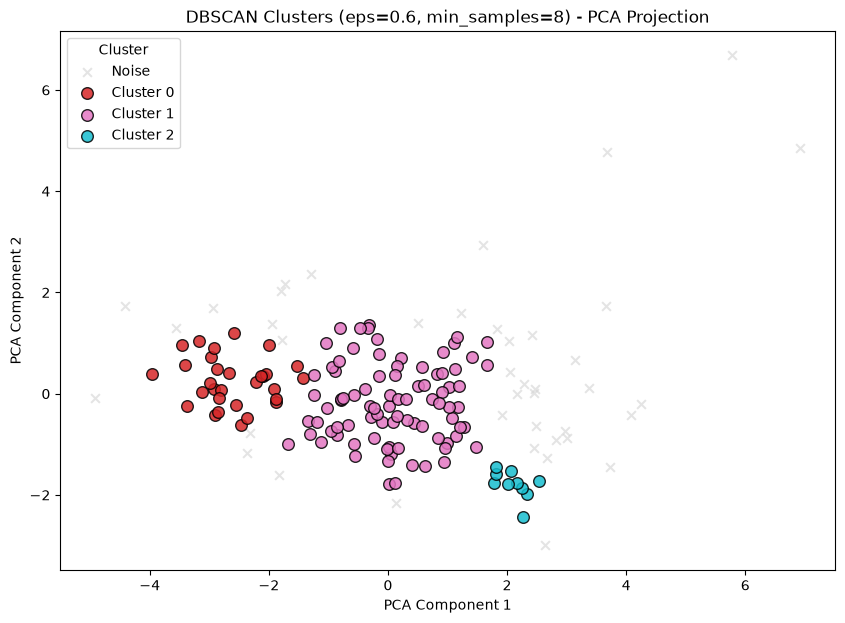

Number of clusters: 3
Number of noise points: 41


In [98]:
import matplotlib.pyplot as plt
import numpy as np

best_db = DBSCAN(eps=0.6, min_samples=8)
labels = best_db.fit_predict(pca_result)

df['cluster_dbscan'] = labels

plt.figure(figsize=(10, 7))

unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = labels == label
    if label == -1:
        # Noise points: gray, small, distinct marker
        plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                    c='lightgray', marker='x', s=40, label='Noise', alpha=0.6)
    else:
        plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                    color=color, s=70, edgecolor='k', label=f'Cluster {label}', alpha=0.85)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('DBSCAN Clusters (eps=0.6, min_samples=8) - PCA Projection')
plt.legend(title='Cluster')
plt.show()

print(f"Number of clusters: {len(unique_labels) - (1 if -1 in unique_labels else 0)}")
print(f"Number of noise points: {list(labels).count(-1)}")